# **Predictive Market Modeling - Bitcoin Forecasting System using Deep Learning (RNN vs LSTM vs GRU)**

## **Project Overview**

This project evaluates the effectiveness of three distinct sequential neural network architectures—Simple Recurrent Neural Networks (RNN), Long Short-Term Memory (LSTM), and Gated Recurrent Units (GRU)—in predicting the highly volatile price trajectory of Bitcoin. By leveraging historical market data, the system processes 60-day lookback windows to forecast short-term future prices. The core objective is to identify which architecture best captures long-term dependencies and manages the vanishing gradient problem inherent in financial time-series data.

## **Import Library**

In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout

## **Data loading & Preprocessing**

In [13]:
df = yf.download('BTC-USD', period='5y')
data = df[['Close']].dropna().values

/tmp/ipykernel_1560/1761286170.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD', period='5y')
[*********************100%***********************]  1 of 1 completed


The model pulls 5 years of live Bitcoin data directly via the yfinance API, ensuring the dataset is robust and reflects real market cycles.

In [14]:
len(data)

1827

In [15]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

seq_length = 60 # Lookback window
X, y = create_sequences(scaled_data, seq_length)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

Using **MinMaxScaler** to compress prices between 0 and 1 is mathematically required because neural networks struggle to calculate weights on raw numbers in the tens of thousands

# **Model Building & Training**

## **Building RNN Model**

In [18]:
rnn_model = Sequential()
rnn_model.add(SimpleRNN(50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
rnn_model.add(Dropout(0.2))
rnn_model.add(Dense(1))

rnn_model.compile(optimizer='adam', loss='mean_squared_error')

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
rnn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

## **Building LSTM Model**

In [20]:
lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

## **Building GRU Model**

In [21]:
gru_model = Sequential()
gru_model.add(GRU(50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
gru_model.add(Dropout(0.2))
gru_model.add(Dense(1))

gru_model.compile(optimizer='adam', loss='mean_squared_error')

gru_model.summary()

Building GRU Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
gru_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

## **Making predictions**

In [25]:
rnn_pred = scaler.inverse_transform(rnn_model.predict(X_test, verbose=0))
lstm_pred = scaler.inverse_transform(lstm_model.predict(X_test, verbose=0))
gru_pred = scaler.inverse_transform(gru_model.predict(X_test, verbose=0))

In [26]:
y_test_actual = scaler.inverse_transform(y_test)

### **Calculate and print Error Metrics**

In [34]:
def evaluate_model(name, actual, predicted):
    mse = mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    print(f"{name} - MSE: {mse:,.2f} | MAE: ${mae:,.2f}")

print("\nModel Evaluation (Test Set)")
evaluate_model("RNN ", y_test_actual, rnn_pred)
evaluate_model("LSTM", y_test_actual, lstm_pred)
evaluate_model("GRU ", y_test_actual, gru_pred)


Model Evaluation (Test Set)
RNN  - MSE: 12,684,562.44 | MAE: $2,777.78
LSTM - MSE: 11,272,341.82 | MAE: $2,505.93
GRU  - MSE: 5,459,225.09 | MAE: $1,769.77


GRU heavily outperformed the standard RNN and even beat the LSTM here. The baseline RNN has a very short memory; it forgets data from day 1 by the time it reaches day 60. The LSTM and GRU both solve this using mathematical "gates" to pass memory along. However, GRU is often superior on smaller, noisier datasets (like a single Bitcoin price feature) because its internal architecture is streamlined, making it less prone to overfitting compared to the heavier LSTM.

## **Future Forecasting (Next 7 Days)**

In [35]:
future_days = 7

# Grabing the last 60 days of scaled data
last_60_days = scaled_data[-seq_length:]

def predict_future(model, initial_sequence, days):
    predictions = []
    current_seq = initial_sequence.copy()

    for _ in range(days):
        current_seq_reshaped = current_seq.reshape((1, seq_length, 1))
        next_pred = model.predict(current_seq_reshaped, verbose=0)
        predictions.append(next_pred[0, 0])
        current_seq = np.append(current_seq[1:], next_pred)

    return predictions

# Generate future predictions
rnn_future = predict_future(rnn_model, last_60_days, future_days)
lstm_future = predict_future(lstm_model, last_60_days, future_days)
gru_future = predict_future(gru_model, last_60_days, future_days)

# Convert back to USD
rnn_future_prices = scaler.inverse_transform(np.array(rnn_future).reshape(-1, 1))
lstm_future_prices = scaler.inverse_transform(np.array(lstm_future).reshape(-1, 1))
gru_future_prices = scaler.inverse_transform(np.array(gru_future).reshape(-1, 1))

future_dates = [(datetime.date.today() + datetime.timedelta(days=i)).strftime('%Y-%m-%d') for i in range(1, future_days + 1)]

future_df = pd.DataFrame({
    'Date': future_dates,
    'RNN_Forecast': rnn_future_prices.flatten(),
    'LSTM_Forecast': lstm_future_prices.flatten(),
    'GRU_Forecast': gru_future_prices.flatten()
})

print("\n7-Day Future Forecast")
print(future_df)


7-Day Future Forecast
         Date  RNN_Forecast  LSTM_Forecast  GRU_Forecast
0  2026-05-25  76299.851562   77430.375000  76447.679688
1  2026-05-26  74264.437500   77319.250000  76390.437500
2  2026-05-27  73465.632812   77273.093750  76332.320312
3  2026-05-28  73843.132812   77275.687500  76273.578125
4  2026-05-29  72457.796875   77315.671875  76214.531250
5  2026-05-30  72379.968750   77384.710938  76155.257812
6  2026-05-31  72349.195312   77476.593750  76095.750000


## **Data Visualization**


Step 7: Generating comparison charts...


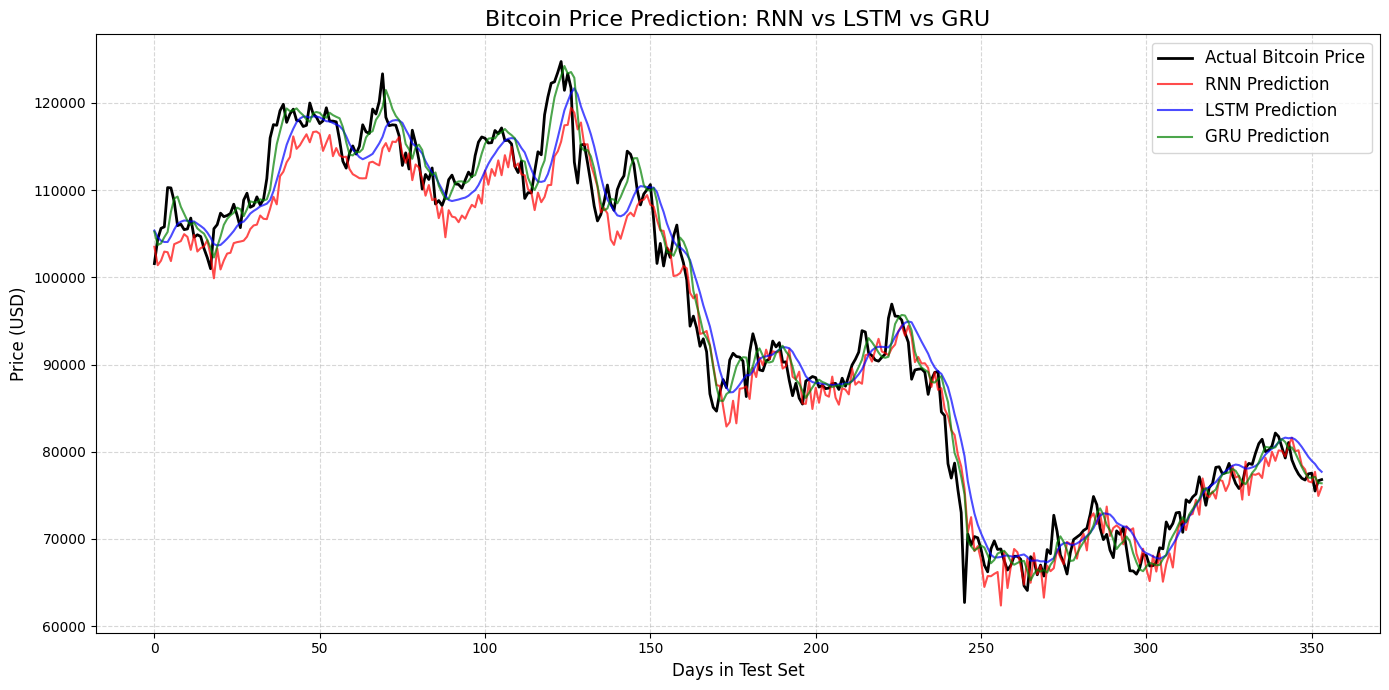

In [31]:
# Historical Testing Data vs Predictions

plt.figure(figsize=(14, 7))
plt.plot(y_test_actual, label='Actual Bitcoin Price', color='black', linewidth=2)
plt.plot(rnn_pred, label='RNN Prediction', color='red', alpha=0.7)
plt.plot(lstm_pred, label='LSTM Prediction', color='blue', alpha=0.7)
plt.plot(gru_pred, label='GRU Prediction', color='green', alpha=0.7)

plt.title('Bitcoin Price Prediction: RNN vs LSTM vs GRU', fontsize=16)
plt.xlabel('Days in Test Set', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

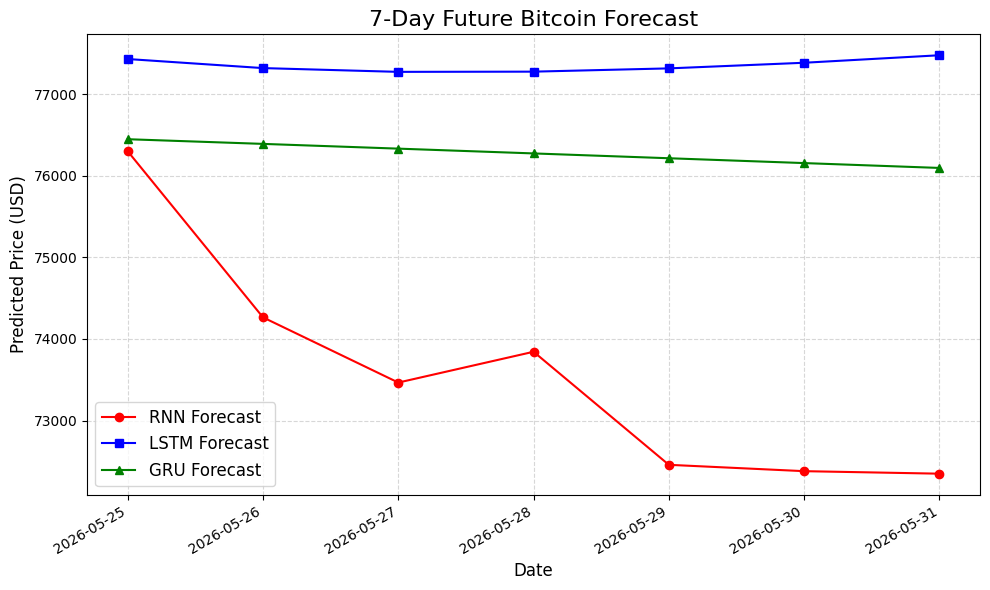

In [36]:
# Future 7-Day Forecast

plt.figure(figsize=(10, 6))
dates = pd.to_datetime(future_df['Date'])

plt.plot(dates, future_df['RNN_Forecast'], label='RNN Forecast', color='red', marker='o')
plt.plot(dates, future_df['LSTM_Forecast'], label='LSTM Forecast', color='blue', marker='s')
plt.plot(dates, future_df['GRU_Forecast'], label='GRU Forecast', color='green', marker='^')

plt.title('7-Day Future Bitcoin Forecast', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Predicted Price (USD)', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()